<a href="https://colab.research.google.com/github/fabrizzio2901/TelecomX-Datos/blob/main/telecomx_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Extracción de datos**

In [60]:
import pandas as pd

url= "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"

In [61]:
# Cargar los datos
df_telecom= pd.read_json(url)

# Exploración inicial rápida
df_telecom.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#**Conoce el conjunto de datos**

In [62]:
# Ver una lista completa de todas las columnas disponibles
df_telecom.columns.tolist()

['customerID', 'Churn', 'customer', 'phone', 'internet', 'account']

In [63]:
# Ver los tipos de datos específicos de cada columna
df_telecom.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


In [64]:
# Resumen general (nulos y tipos)
df_telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


#**Manejo de inconsistencias**

In [65]:
# Extraer y aplanar los diccionarios de cada columna
df_customer = pd.json_normalize(df_telecom['customer'])
df_phone    = pd.json_normalize(df_telecom['phone'])
df_internet = pd.json_normalize(df_telecom['internet'])
df_account  = pd.json_normalize(df_telecom['account'])

In [66]:
# Unir todo en un nuevo DataFrame plano, conservando el ID y el Churn
df_flat = pd.concat([df_telecom[['customerID', 'Churn']], df_customer, df_phone, df_internet, df_account], axis=1)

In [67]:
# Seleccionamos solo las columnas que son de tipo texto (object)
columnas_texto = df_flat.select_dtypes(include=['object']).columns

In [68]:
# Excluimos el 'customerID' porque ese código sí debe mantener sus mayúsculas originales
columnas_texto = columnas_texto.drop('customerID')

In [69]:
# Aplicamos .str.lower() a todas las columnas de texto restantes
for col in columnas_texto:
    df_flat[col] = df_flat[col].str.lower()
    df_flat[col] = df_flat[col].str.strip() # Eliminamos espacios extra al inicio/final

In [70]:
# Exploración inicial rápida
df_flat.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,no,female,0,yes,yes,9,yes,no,dsl,...,yes,no,yes,yes,no,one year,yes,mailed check,65.6,593.3
1,0003-MKNFE,no,male,0,no,no,9,yes,yes,dsl,...,no,no,no,no,yes,month-to-month,no,mailed check,59.9,542.4
2,0004-TLHLJ,yes,male,0,no,no,4,yes,no,fiber optic,...,no,yes,no,no,no,month-to-month,yes,electronic check,73.9,280.85
3,0011-IGKFF,yes,male,1,yes,no,13,yes,no,fiber optic,...,yes,yes,no,yes,yes,month-to-month,yes,electronic check,98.0,1237.85
4,0013-EXCHZ,yes,female,1,yes,no,3,yes,no,fiber optic,...,no,no,yes,yes,no,month-to-month,yes,mailed check,83.9,267.4


In [71]:
import numpy as np

columna_total = 'Charges.Total'

# Reemplazamos los espacios vacíos o en blanco por nulos de Numpy (NaN)
df_flat[columna_total] = df_flat[columna_total].replace([" ", "", "  "], np.nan)

In [72]:
# Convertimos la columna a formato numérico (float)
df_flat[columna_total] = pd.to_numeric(df_flat[columna_total])

In [73]:
# Contar cuántos valores nulos hay en cada columna
nulos_totales = df_flat.isnull().sum()
print(nulos_totales[nulos_totales > 0])

Charges.Total    11
dtype: int64


In [74]:
# Rellenar los 11 valores nulos con 0
df_flat['Charges.Total'] = df_flat['Charges.Total'].fillna(0)

# Verificación final
nulos_finales = df_flat['Charges.Total'].isnull().sum()
print(nulos_finales)

0


#**Comprobación de incoherencias en los datos**

In [92]:
# Seleccionamos las columnas de texto, excluyendo el ID del cliente
columnas_categoricas = df_flat.select_dtypes(include=['object']).columns
if 'customerID' in columnas_categoricas:
    columnas_categoricas = columnas_categoricas.drop('customerID')

In [91]:
# Imprimimos los valores únicos de cada columna
for col in columnas_categoricas:
    print(f"\n Valores únicos en la columna '{col}':")
    print(df_flat[col].unique())


 Valores únicos en la columna 'Churn':
['no' 'yes']

 Valores únicos en la columna 'gender':
['female' 'male']

 Valores únicos en la columna 'Partner':
['yes' 'no']

 Valores únicos en la columna 'Dependents':
['yes' 'no']

 Valores únicos en la columna 'PhoneService':
['yes' 'no']

 Valores únicos en la columna 'MultipleLines':
['no' 'yes']

 Valores únicos en la columna 'InternetService':
['dsl' 'fiber optic' 'no']

 Valores únicos en la columna 'OnlineSecurity':
['no' 'yes']

 Valores únicos en la columna 'OnlineBackup':
['yes' 'no']

 Valores únicos en la columna 'DeviceProtection':
['no' 'yes']

 Valores únicos en la columna 'TechSupport':
['yes' 'no']

 Valores únicos en la columna 'StreamingTV':
['yes' 'no']

 Valores únicos en la columna 'StreamingMovies':
['no' 'yes']

 Valores únicos en la columna 'Contract':
['one year' 'month-to-month' 'two year']

 Valores únicos en la columna 'PaperlessBilling':
['yes' 'no']

 Valores únicos en la columna 'PaymentMethod':
['mailed check

In [82]:
# Eliminar las filas donde el Churn está vacío
df_flat = df_flat[df_flat['Churn'] != '']


In [83]:
# Simplificar "no internet service" a "no" usando replace
columnas_servicios_internet = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection','TechSupport', 'StreamingTV', 'StreamingMovies']

for col in columnas_servicios_internet:
    df_flat[col] = df_flat[col].replace('no internet service', 'no')

In [84]:
# Simplificar "no phone service" a "no" usando replace
df_flat['MultipleLines'] = df_flat['MultipleLines'].replace('no phone service', 'no')

In [89]:
# Seleccionamos las columnas de texto, excluyendo el ID del cliente
columnas_categoricas = df_flat.select_dtypes(include=['object']).columns
if 'customerID' in columnas_categoricas:
    columnas_categoricas = columnas_categoricas.drop('customerID')


In [90]:
# Imprimimos los valores únicos de cada columna
for col in columnas_categoricas:
    print(f"\n Valores únicos en la columna '{col}':")
    print(df_flat[col].unique())


 Valores únicos en la columna 'Churn':
['no' 'yes']

 Valores únicos en la columna 'gender':
['female' 'male']

 Valores únicos en la columna 'Partner':
['yes' 'no']

 Valores únicos en la columna 'Dependents':
['yes' 'no']

 Valores únicos en la columna 'PhoneService':
['yes' 'no']

 Valores únicos en la columna 'MultipleLines':
['no' 'yes']

 Valores únicos en la columna 'InternetService':
['dsl' 'fiber optic' 'no']

 Valores únicos en la columna 'OnlineSecurity':
['no' 'yes']

 Valores únicos en la columna 'OnlineBackup':
['yes' 'no']

 Valores únicos en la columna 'DeviceProtection':
['no' 'yes']

 Valores únicos en la columna 'TechSupport':
['yes' 'no']

 Valores únicos en la columna 'StreamingTV':
['yes' 'no']

 Valores únicos en la columna 'StreamingMovies':
['no' 'yes']

 Valores únicos en la columna 'Contract':
['one year' 'month-to-month' 'two year']

 Valores únicos en la columna 'PaperlessBilling':
['yes' 'no']

 Valores únicos en la columna 'PaymentMethod':
['mailed check

In [78]:
# Contar cuántas filas son copias exactas de otra
duplicados = df_flat.duplicated().sum()
print(duplicados)

0


#**Columna de cuentas diarias (Opcional)**

In [94]:
columna_mensual = 'Charges.Monthly'

# Creamos la nueva columna dividiendo entre 30 y redondeando a 2 decimales
df_flat['Cuentas_Diarias'] = (df_flat[columna_mensual] / 30).round(2)


In [96]:
# Vista
print(df_flat[[columna_mensual, 'Cuentas_Diarias']].head())

   Charges.Monthly  Cuentas_Diarias
0             65.6             2.19
1             59.9             2.00
2             73.9             2.46
3             98.0             3.27
4             83.9             2.80


##**📊 Carga y análisis(L - Load & Analysis)**

In [99]:
# 1. Análisis descriptivo de las variables NUMÉRICAS
print("Estadísticas descriptivas")
display(df_flat.describe().round(2))

Estadísticas descriptivas


,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7043.00,7043.00,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76,2279.73,2.16
std,0.37,24.56,30.09,2266.79,1.00
min,0.00,0.00,18.25,0.00,0.61
25%,0.00,9.00,35.50,398.55,1.18
50%,0.00,29.00,70.35,1394.55,2.34
75%,0.00,55.00,89.85,3786.60,2.99
max,1.00,72.00,118.75,8684.80,3.96


In [100]:
# Análisis descriptivo de las variables CATEGÓRICAS (texto)
print("Estadísticas descriptivas (Variables Categóricas):")
display(df_flat.describe(include=['object']))

Estadísticas descriptivas (Variables Categóricas):


,customerID,Churn,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,2,2,3,2,2,2,2,2,2,3,2,4
top,9995-HOTOH,no,male,no,no,yes,no,fiber optic,no,no,no,no,no,no,month-to-month,yes,electronic check
freq,1,5174,3555,3641,4933,6361,4072,3096,5024,4614,4621,4999,4336,4311,3875,4171,2365


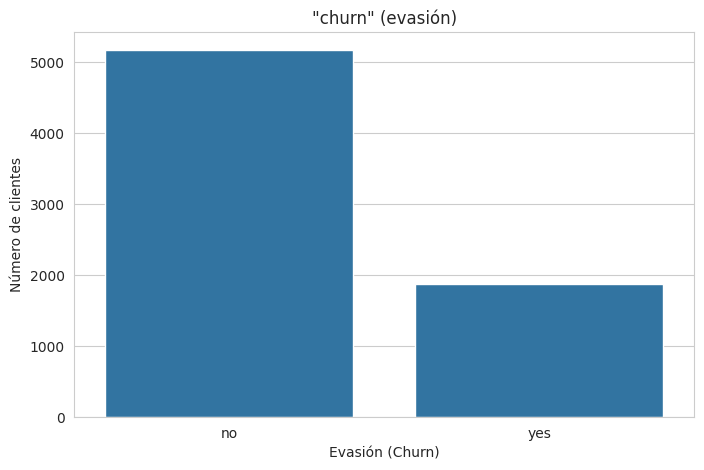

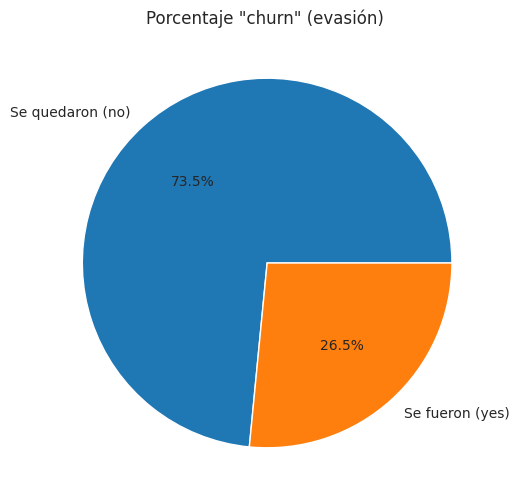

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

# GRÁFICO DE BARRAS

# Le damos un tamaño al gráfico (ancho, alto)
plt.figure(figsize=(8, 5))

# Usamos seaborn para contar cuántos 'yes' y 'no' hay en la columna Churn
sns.countplot(data=df_flat, x='Churn')

# Le ponemos títulos para que se entienda qué estamos viendo
plt.title('"churn" (evasión)')
plt.xlabel('Evasión (Churn)')
plt.ylabel('Número de clientes')

# Mostramos este primer gráfico
plt.show()

# GRÁFICO DE PASTEL

# Hacemos un nuevo gráfico cuadradito
plt.figure(figsize=(6, 6))

# Primero contamos cuántos clientes hay de cada categoría
conteo_churn = df_flat['Churn'].value_counts()

# Dibujamos el pastel
plt.pie(conteo_churn,
        labels=['Se quedaron (no)', 'Se fueron (yes)'],
        autopct='%1.1f%%')

# Su título
plt.title('Porcentaje "churn" (evasión) ')

# Mostramos el pastel
plt.show()

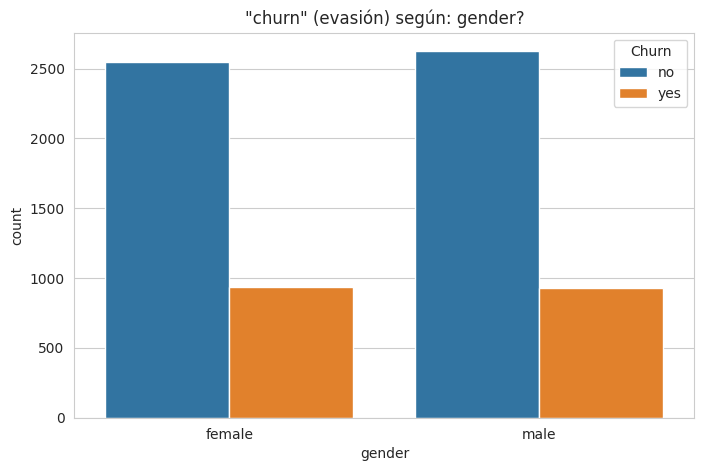

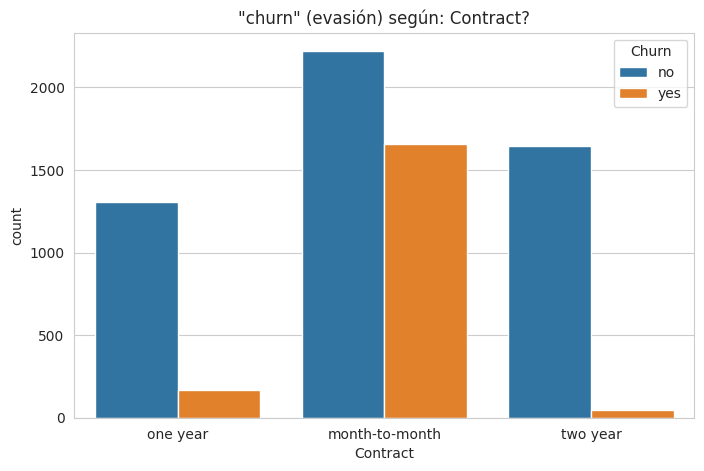

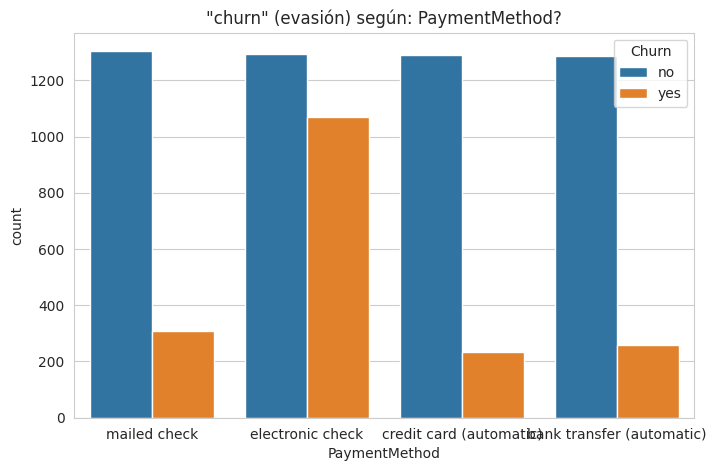

In [106]:
# Hacemos una lista de las tres cosas que queremos investigar
columnas = ['gender', 'Contract', 'PaymentMethod']

# Usamos un 'for' para que Python haga los 3 gráficos
for col in columnas:

    # Preparamos un lienzo de tamaño normal
    plt.figure(figsize=(8, 5))

    # Hacemos el gráfico de barras.
    sns.countplot(data=df_flat, x=col, hue='Churn')

    # Le ponemos un título
    plt.title('"churn" (evasión) según: ' + col + '?')

    # Mostramos el gráfico en pantalla
    plt.show()

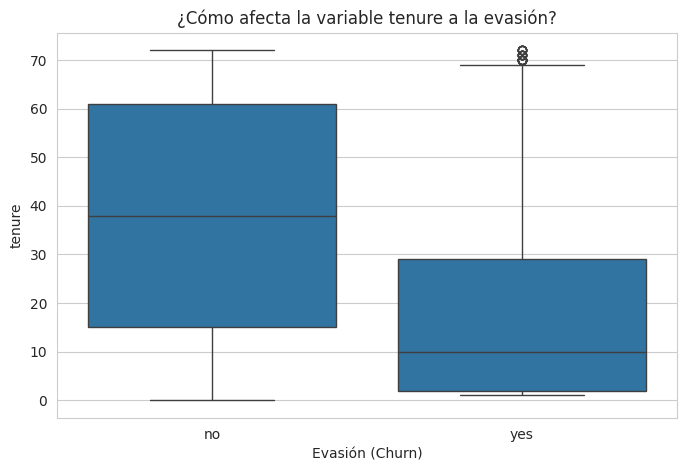

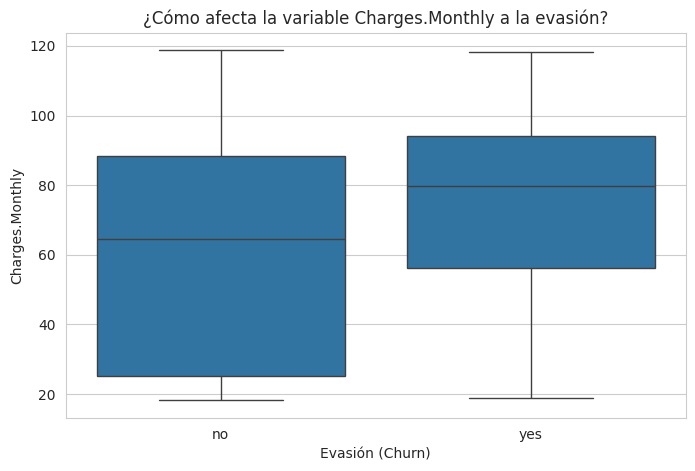

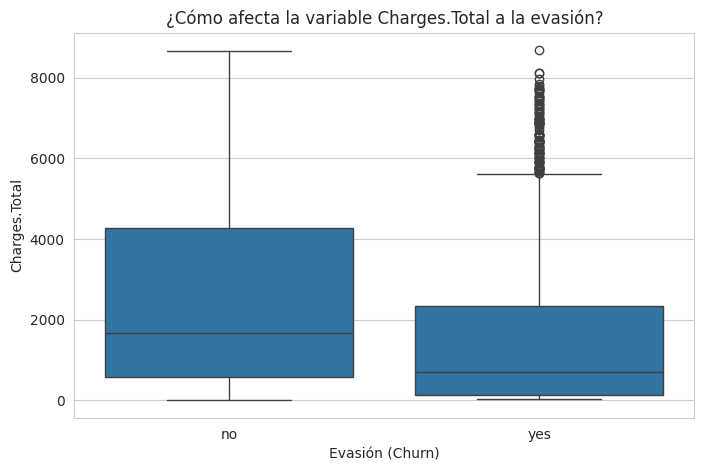

In [109]:
# Hacemos una lista de las columnas que tienen números
columnas_numericas = ['tenure', 'Charges.Monthly', 'Charges.Total']

# Usamos un 'for' para hacer los 3 gráficos
for col in columnas_numericas:

    # Preparamos un lienzo
    plt.figure(figsize=(8, 5))

    # Hacemos el diagrama de caja (boxplot).
    # 'x' separa en dos grupos: los que se van y los que se quedan.
    # 'y' pone los números (meses, dinero, etc.) hacia arriba.
    sns.boxplot(data=df_flat, x='Churn', y=col)

    # Le ponemos un título
    plt.title('¿Cómo afecta la variable ' + col + ' a la evasión?')
    plt.xlabel('Evasión (Churn)')
    plt.ylabel(col)

    # Mostramos el gráfico en pantalla
    plt.show()

# Informe Final: Proyecto - Telecom X

##  Introducción
El objetivo principal de este análisis fue investigar el problema de evasión de clientes (Churn) en la empresa Telecom X. La compañía enfrenta una alta tasa de cancelaciones y necesitaba entender los motivos detrás de estas fugas. A través de este proyecto, extrajimos los datos, los preparamos y creamos visualizaciones sencillas para descubrir patrones de comportamiento y así ayudar a tomar decisiones estratégicas.

##  Limpieza y Tratamiento de Datos (ETL)
Para asegurar que nuestro análisis no tuviera errores, limpiamos a fondo la base de datos:
* **Extracción:** Importamos los datos directamente desde la API usando Python y Pandas.
* **Desempaquetado:** Acomodamos la información que venía "escondida" en diccionarios (como los datos de la cuenta y el internet) para ver todas las columnas claras.
* **Estandarización:** Pasamos todos los textos a minúsculas y quitamos opciones repetitivas (como cambiar "no internet service" a solo "no").
* **Corrección de Nulos:** Encontramos que había clientes nuevos sin "cargos totales" registrados. Rellenamos esos espacios vacíos con `0` para no perder la información.
* **Nuevas Variables:** Creamos una columna de `Cuentas_Diarias` dividiendo el pago mensual entre 30, para entender mejor el gasto del cliente día a día.

##  Análisis Exploratorio de Datos (EDA)
Hicimos varias gráficas para entender visualmente qué estaba pasando:
* **Cantidades Exactas:** Usamos gráficos de barras y de pastel para ver exactamente cuántos clientes se estaban yendo.
* **Análisis por Categorías:** Comparamos a los clientes que se van según su género, el tipo de contrato que tienen y cómo pagan.
* **Análisis de Números:** Usamos gráficos de distribución para ver en qué meses de antigüedad renuncia más la gente y cuánto pagaban de mensualidad.

##  Conclusiones e Insights (Descubrimientos)
Al ver las gráficas, encontramos a los "sospechosos principales" de las cancelaciones:
* **El Contrato Mes a Mes es el mayor riesgo:** Casi todos los clientes que cancelan tienen un contrato mensual. Los que tienen contratos de uno o dos años casi no se van.
* **Peligro en los primeros meses:** Las gráficas mostraron un pico altísimo de cancelaciones justo al inicio. Si el cliente no se va rápido, suele quedarse mucho tiempo.
* **Cargos altos:** Los clientes que pagan las mensualidades más caras son los que más rápido abandonan el servicio.
* **Problemas con el Cheque Electrónico:** Vimos que los clientes que usan el "Electronic check" para pagar, se van mucho más que los que usan tarjeta o transferencia.

##  Recomendaciones
Basado en estos números, le sugiero a Telecom X las siguientes estrategias:
1. **Premiar los contratos largos:** Ofrecer descuentos o regalos para convencer a los clientes "mes a mes" de que cambien a un contrato de un año.
2. **Consentir a los nuevos:** Darle seguimiento especial y soporte técnico de primera a los clientes nuevos durante sus primeros meses, que es cuando más deciden irse.
3. **Revisar los paquetes caros:** Asegurarse de que los servicios más costosos realmente estén funcionando bien, porque la gente que paga más es la menos satisfecha.
4. **Investigar la forma de pago:** El equipo técnico debería revisar si pagar con Cheque Electrónico está fallando o es muy complicado, porque está alejando a los clientes.